# RNA/ADT interpretability tutorial

This tutorial shows how to run Champollion on a processed RNA/ADT dataset and then inspect the learned interaction matrix `A`. The goal is to illustrate the main steps of the workflow and the main result objects, not to provide a full analysis recipe.

The dataset used here is already preprocessed. For guidance on preparing a new dataset, see the Data Inputs section of the documentation.


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from pathlib import Path

import muon as mu
import numpy as np
import pandas as pd
from gprofiler import GProfiler
from IPython.display import display

from champollion import Champollion
from champollion.plot import plot_aggregated_transport_plan, top_interactions_bar

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## Configuration

In [8]:
DATA_PATH = Path(
    "../semi-paired/data/cite_opp_tuto_processed.h5mu"
)

RNA_MOD = "rna"
ADT_MOD = "adt"
CELLTYPE_KEY = "celltype"

## Prepare the tutorial inputs

This dataset is fully paired, but in this tutorial we split it to mimic the semi-paired setting Champollion is designed for. This setup detail is made optional as it is not central to the point of this tutorial. For your own data and preprocessing choices, see the Data Inputs section of the documentation.

After this preparation step, we will have three objects: one bridge `MuData` object used for fitting, plus one pseudo-unpaired RNA object and one pseudo-unpaired ADT object used for transport and interpretation.


In [9]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Update DATA_PATH for your local data location."
    )

mdata = mu.read_h5mu(DATA_PATH)
print(mdata)
print("modalities:", list(mdata.mod.keys()))

MuData object with n_obs × n_vars = 10966 × 14087
  obs:	'celltype', 'fine_celltype', 'paired_mask'
  uns:	'dataset_name'
  2 modalities
    adt:	10966 × 134
      obs:	'batch', 'Site', 'DonorNumber', 'celltype', 'fine_celltype'
      var:	'feature_types', 'gene_id', 'variability_score', 'mean', 'std'
      obsm:	'X_pca', 'prior_data'
      layers:	'counts', 'scaled'
    rna:	10966 × 13953
      obs:	'batch', 'Site', 'DonorNumber', 'celltype', 'fine_celltype', 'n_genes'
      var:	'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
      uns:	'hvg', 'log1p'
      obsm:	'X_pca', 'prior_data'
      layers:	'counts', 'scaled'
modalities: ['adt', 'rna']


In [11]:
PAIRED_MASK_KEY = "paired_mask"

DEBUG = False
N_HVG = 250 if DEBUG else 4000
DEBUG_TRAIN_CELLS = 60
DEBUG_TEST_CELLS = 80

coding_genes = ["TNFRSF4", "TNFRSF14", "TNFRSF9", "CD52", "CD58", "CD2", "CD101", "FCGR1A", "CD1D", "CD1C", "FCER1A", "SLAMF6", "CD48", "SLAMF7", "CD244", "FCGR2A", "FCGR3A", "SELL", "PTPRC", "CR2", "CR1", "CD8A", "DPP4", "ITGA6", "ITGA4", "CD28", "CTLA4", "ICOS", "CCR4", "CX3CR1", "CCR2", "CCR5", "CD47", "BTLA", "TIGIT", "CD86", "TFRC", "CD38", "IL7R", "ITGA1", "CD14", "CSF1R", "CD83", "HLA-A", "HLA-E", "HLA-C", "HLA-B", "HLA-DRA", "NT5E", "CD24", "IFNGR1", "CCR6", "CD36", "CD72", "ENG", "IL2RA", "ITGB1", "NRP1", "FAS", "ENTPD1", "CD81", "CD44", "CD82", "MS4A1", "CD5", "NCAM1", "CD3G", "CXCR5", "CD9", "CD27", "LAG3", "CD4", "CD163", "CLEC4C", "KLRG1", "KLRB1", "CD69", "KLRD1", "KLRK1", "ITGB7", "CD63", "SELPLG", "LAMP1", "TRAC", "IGHD", "IGHM", "ANPEP", "IL4R", "CD19", "ITGAL", "ITGAM", "ITGAX", "ITGAE", "GP1BA", "CD79B", "PECAM1", "CD7", "CD226", "FCER2", "ICAM1", "CD22", "PVR", "NECTIN2", "C5AR1", "SIGLEC7", "CD33", "LILRB1", "NCR1", "SIRPA", "THBD", "CD93", "CD40", "ITGB2", "IL2RB", "TNFRSF13C", "IL3RA", "CD40LG"]

CELLTYPE_ORDER = ["HSC", "Lymph prog", "G/M prog", "MK/E prog", "Proerythroblast", "Erythroblast", "Normoblast", "Reticulocyte", "CD14+ Mono", "CD16+ Mono", "cDC2", "pDC", "Naive CD20+ B", "Transitional B", "B1 B", "Plasma cell", "Plasmablast", "CD4+ T naive", "CD4+ T", "CD4+ T activated", "CD8+ T naive", "CD8+ T", "ILC1", "NK", "MAIT"]

def get_hvg_names(adata, n_features=4000, keep_features=None):
    """Return HVGs, optionally forcing a set of biologically linked genes to stay."""
    if "variability_score" not in adata.var:
        raise KeyError(
            "Expected adata.var['variability_score'] in the processed RNA object."
        )

    var_annot = adata.var.sort_values(ascending=False, by="variability_score")
    n_features = min(n_features, len(var_annot))
    min_score = var_annot["variability_score"].iloc[n_features - 1]
    mask = adata.var["variability_score"] >= min_score

    if keep_features is not None:
        keep_features = [gene for gene in keep_features if gene in mask.index]
        mask.loc[keep_features] = True

    return list(adata.var_names[mask])


gene_names = get_hvg_names(
    mdata.mod[RNA_MOD], n_features=N_HVG, keep_features=coding_genes
)

paired_mask = np.asarray(mdata.obs[PAIRED_MASK_KEY].to_numpy(), dtype=bool)
celltypes = mdata.obs[CELLTYPE_KEY].astype(str).to_numpy()

def stratified_indices(mask, labels, n=None, random_state=0):
    """Return indices within mask, optionally stratified down to n cells."""
    idx = np.flatnonzero(mask)
    if n is None or n >= len(idx):
        return idx

    rng = np.random.default_rng(random_state)
    selected = []
    present_labels = [
        label for label in pd.unique(labels[idx]) if np.any(labels[idx] == label)
    ]
    per_group = max(1, int(np.ceil(n / len(present_labels))))
    for label in present_labels:
        label_idx = idx[labels[idx] == label]
        take = min(per_group, len(label_idx))
        selected.extend(rng.choice(label_idx, size=take, replace=False))
    selected = np.asarray(selected, dtype=int)
    if len(selected) > n:
        selected = rng.choice(selected, size=n, replace=False)
    return np.sort(selected)


train_idx = stratified_indices(
    paired_mask,
    labels=celltypes,
    n=DEBUG_TRAIN_CELLS if DEBUG else None,
    random_state=0,
)
test_idx = stratified_indices(
    ~paired_mask,
    labels=celltypes,
    n=DEBUG_TEST_CELLS if DEBUG else None,
    random_state=1,
)

train_mdata = mu.MuData(
    {
        RNA_MOD: mdata.mod[RNA_MOD][train_idx, gene_names].copy(),
        ADT_MOD: mdata.mod[ADT_MOD][train_idx].copy(),
    }
)

adata_rna = mdata.mod[RNA_MOD][test_idx, gene_names].copy()
adata_adt = mdata.mod[ADT_MOD][test_idx].copy()

In [12]:
print("training bridge data:")
print(train_mdata)
print("pseudo-unpaired RNA:", adata_rna.shape)
print("pseudo-unpaired ADT:", adata_adt.shape)
print(f"RNA features kept for A: {len(gene_names)}")
print(f"ADT proteins kept for A: {adata_adt.n_vars}")

training bridge data:
MuData object with n_obs × n_vars = 8783 × 4165
  2 modalities
    rna:	8783 × 4031
      obs:	'batch', 'Site', 'DonorNumber', 'celltype', 'fine_celltype', 'n_genes'
      var:	'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variability_score', 'mean', 'std'
      uns:	'hvg', 'log1p'
      obsm:	'X_pca', 'prior_data'
      layers:	'counts', 'scaled'
    adt:	8783 × 134
      obs:	'batch', 'Site', 'DonorNumber', 'celltype', 'fine_celltype'
      var:	'feature_types', 'gene_id', 'variability_score', 'mean', 'std'
      obsm:	'X_pca', 'prior_data'
      layers:	'counts', 'scaled'
pseudo-unpaired RNA: (2183, 4031)
pseudo-unpaired ADT: (2183, 134)
RNA features kept for A: 4031
ADT proteins kept for A: 134


## Fit Champollion

Fitting learns the matrix `A` from the bridge cells. Because this tutorial uses direct scaled RNA and ADT features, rows and columns of `A` can be read as gene-protein association scores. 


In [13]:
model = Champollion(
    epsilon=1.0,
    gamma=0.01,
    lambda_prior=20.0,
    use_keops=False,
    device="auto",
    random_state=0,
    max_iter=2 if DEBUG else 300_000,
    learning_rate=1e-3,
    sinkhorn_tol=1e-3,
    log_every=1 if DEBUG else 40,
    verbose=True,
)
model.fit(
    train_mdata,
    modality_1=RNA_MOD,
    modality_2=ADT_MOD,
    x_1_rep="layers/scaled",
    x_2_rep="layers/scaled",
)

A_df = model.A_dataframe()
print("A shape:", A_df.shape)
print("A device:", model.A_.device)
pd.DataFrame(
    {key: pd.Series(value) for key, value in model.training_history_.items()}
).tail()

  0%|          | 5/300000 [00:00<12:34:06,  6.63it/s]

train_total_loss: 83.64341735839844
train_obj_loss: 29.6660099029541
train_reg_loss: 53.97740936279297
train_trace_term: 0.28358766436576843
train_err_1: 1.7106705904006958
train_plan_mass: 1.0000009536743164


  0%|          | 44/300000 [00:02<2:43:33, 30.56it/s]

train_total_loss: 36.16069793701172
train_obj_loss: -0.7098903656005859
train_reg_loss: 36.87059020996094
train_trace_term: -17.491703033447266
train_err_1: 0.6642380356788635
train_plan_mass: 1.0000001192092896


  0%|          | 85/300000 [00:03<2:27:05, 33.98it/s]

...

  3%|▎         | 9889/300000 [03:57<1:51:28, 43.37it/s]

train_total_loss: -4.325257301330566
train_obj_loss: -7.067130088806152
train_reg_loss: 2.741872549057007
train_trace_term: -16.846837997436523
train_err_1: 0.001272382098250091
train_plan_mass: 1.0000001192092896


  3%|▎         | 9920/300000 [03:58<1:56:02, 41.67it/s]


train_total_loss: -4.325271129608154
train_obj_loss: -7.067163467407227
train_reg_loss: 2.7418923377990723
train_trace_term: -16.849288940429688
train_err_1: 0.0009368073660880327
train_plan_mass: 1.0000001192092896
Converged after 9921 iterations
train_n_iterations: 9921
train_err_1: 0.0009371092892251909
train_plan_mass: 1.0
train_A_final_norm: 274.18896484375
train_plan_entropy_ratio: tensor([0.7620], device='cuda:0', grad_fn=<DivBackward0>)
A shape: (4031, 134)
A device: cuda:0


,train_total_loss,train_obj_loss,train_reg_loss,train_trace_term,train_err_1,train_plan_mass
245,-4.325231,-7.067060,2.741828,-16.841217,0.001022,1.0
246,-4.325246,-7.067102,2.741857,-16.843895,0.001050,1.0
247,-4.325257,-7.067130,2.741873,-16.846838,0.001272,1.0
248,-4.325271,-7.067163,2.741892,-16.849289,0.000937,1.0
249,NaN,NaN,NaN,NaN,0.000937,1.0


## Transport pseudo-unpaired cells and aggregate the plan

After fitting, we use the learned cost to transport pseudo-unpaired RNA cells to pseudo-unpaired ADT cells.


In [14]:
transport = model.transport(
    {RNA_MOD: adata_rna, ADT_MOD: adata_adt},
    x_reps={RNA_MOD: "layers/scaled", ADT_MOD: "layers/scaled"},
    store_cost=True,
    store_plan=True,
    max_iter_sink=20 if DEBUG else 1000,
)

plan = transport.materialize_plan().detach().cpu().numpy()
print("plan shape:", plan.shape)
print("plan mass:", plan.sum())
transport.plan_diagnostics

plan shape: (2183, 2183)
plan mass: 1.0000002


{'mass': 1.000000238418579,
 'mass_abs_error': 2.384185791015625e-07,
 'x_1_marginal_l1_error': 0.0008025987190194428,
 'x_2_marginal_l1_error': 2.4001928977668285e-07,
 'finite': True,
 'passed': True,
 'tol': 0.001}

## Examine the transport plan

For a quick visualization of the validity of the inferred transport plan, we can use provided cell type annotations to aggregate the transported mass across those labels and check mass is transported between coherent cell populations.

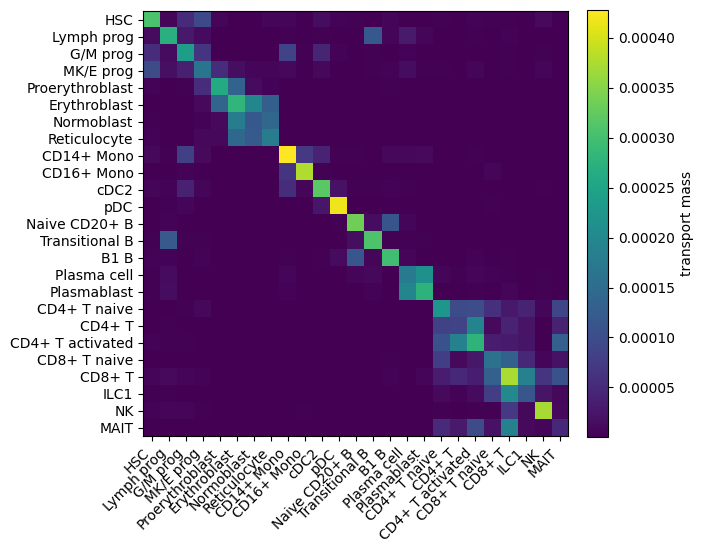

In [15]:
labels_rna = adata_rna.obs[CELLTYPE_KEY].astype(str).to_numpy()
labels_adt = adata_adt.obs[CELLTYPE_KEY].astype(str).to_numpy()

aggregated_plan, fig, ax = plot_aggregated_transport_plan(
    heat_mtx=plan,
    annotations=labels_rna,
    annotations_ordered=CELLTYPE_ORDER,
    annotations_2=labels_adt,
    annotations_ordered_2=CELLTYPE_ORDER,
    cbar_label="transport mass",
    reduction="sum",
)

## Inspect one marker-specific column of A

A column of `A` ranks RNA genes by their contribution to the learned cost for one ADT protein. Here we inspect one familiar B-cell marker as an example of how to query and plot the learned interactions.

,gene,A_score
0,CD24,0.021163
1,WHAMM,0.019635
2,CXXC5,0.019152
3,LINC00926,0.017681
4,MS4A1,0.015109
5,PDLIM1,0.014692
6,BLK,0.014095
7,PAX5,0.013725
8,TRIM59,0.013483
9,ZNF284,0.013372


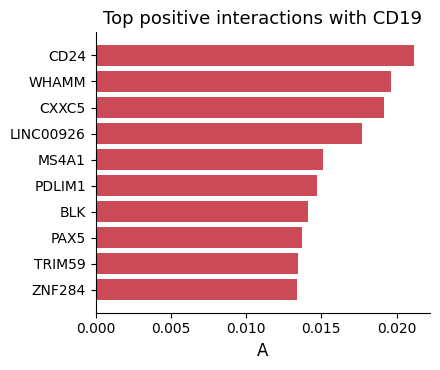

In [16]:
MARKER_PROTEIN = "CD19"
top = model.top_interactions(
    MARKER_PROTEIN,
    modality=ADT_MOD,
    k=10,
    direction="positive",
)
display(
    top[["target_feature", "weight"]].rename(
        columns={"target_feature": "gene", "weight": "A_score"},
    )
)
bar_fig = top_interactions_bar(
    interactions=top,
    title=f"Top positive interactions with {MARKER_PROTEIN}",
    colors="#CA4B55",
)

## Enrichment from one protein-specific A column

The same `A` column can also be used to define a gene set for enrichment. This is only a small example of the downstream analyses enabled by the learned interaction matrix; it requires internet access for g:Profiler.

In [17]:
def genes_for_enrichment(A_df, protein, frac_max=100, max_genes=100):
    if protein not in A_df.columns:
        raise KeyError(f"Protein {protein!r} was not found in A columns.")
    scores = A_df[protein]
    max_abs_score = scores.abs().max()
    if max_abs_score == 0:
        return pd.Series(dtype=float, name=protein)
    selected = scores[scores.abs() > (max_abs_score / frac_max)]
    selected = selected.loc[selected.abs().sort_values(ascending=False).index]
    selected = selected.iloc[:max_genes]
    selected.name = protein
    return selected

In [18]:
ENRICHMENT_PROTEIN = "CD18"
gp = GProfiler(return_dataframe=True)
background = list(A_df.index)

enrichment_input = genes_for_enrichment(
    A_df,
    protein=ENRICHMENT_PROTEIN,
    frac_max=100,
    max_genes=100,
)
print(f"{ENRICHMENT_PROTEIN}: top {len(enrichment_input)} genes")
display(enrichment_input.to_frame("A_score").head(20))

CD18: top 100 genes


,A_score
CD84,0.029304
AC092279.1,-0.026720
ALOX5AP,0.026240
PCNA,0.023267
KBTBD2,0.022768
NRIP1,-0.021693
AC007262.2,0.021638
CD74,0.021350
ITGB2,0.020158
CA5B,0.019774


In [19]:
enrichment_results = gp.profile(
    organism="hsapiens",
    sources=["KEGG", "REAC", "WP", "GO"],
    query=list(enrichment_input.index),
    background=background,
)
display(enrichment_results)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,WP,WP:WP615,Senescence and autophagy in cancer,0.024924,True,Senescence and autophagy in cancer,31,87,8,3521,0.091954,0.258065,query_1,[WP:000000]
